# 06c — Deep Analysis: Feature Importance, Error Analysis & Conclusions (v1.0-trainval)
## Multi-Attribute Scene Classification on nuScenes — Primary Experiment

The conclusive deep analysis on the 150-scene subset: which feature groups drive each attribute,
where errors concentrate, and the answers to the research questions — drawn on the trustworthy
dataset, not the pilot.

> Trains lightweight RF/LR on one representative fold purely for feature-importance (seconds);
> all other analysis reads saved predictions. No full retraining.


## 0. Setup

In [2]:
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def find_project_root():
    p=Path.cwd().resolve()
    for cand in [p,*p.parents]:
        if (cand/'README.md').exists() and (cand/'notebooks').exists(): return cand
    raise FileNotFoundError('Project root not found')
os.chdir(find_project_root())
sns.set_theme(style='whitegrid',context='notebook'); plt.rcParams['figure.dpi']=100
DV='v1.0-trainval'; REPRESENTATIVE_FOLD=0; SEED=42
PROC=Path('data/processed')/DV
FEATURE_DIR=PROC/'features'; SPLIT_DIR=PROC/'splits'; LABEL_DIR=PROC/'labels'
RESULTS_DIR=Path('results')/DV/'metrics'; PRED_DIR=Path('results')/DV/'predictions'
FINAL_DIR=Path('results')/DV/'final'; FINAL_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=Path('results')/DV/'figures'/'final'; FIG_DIR.mkdir(parents=True,exist_ok=True)
ATTRIBUTES=['time_of_day','weather','vehicle_density','vru_present']
CLASS_ORDERS={'time_of_day':['day','night'],'weather':['clear','rain'],
              'vehicle_density':['low','medium','high'],'vru_present':['absent','present']}
print('Setup OK |',os.getcwd())

Setup OK | C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Reconstruct Representative Fold (train/test) from saved splits

trainval has no `fold_N_train.csv`; we rebuild fold 0 from `sample_fold_assignments.csv` + features.

In [3]:
feat=pd.read_csv(FEATURE_DIR/'features_full.csv')
folds=pd.read_csv(SPLIT_DIR/'sample_fold_assignments.csv')
labels=pd.read_csv(LABEL_DIR/'attribute_labels.csv')
# derive feature columns from headers (robust; no dependence on JSON key names)
FEATURE_COLS=[c for c in feat.columns if c.startswith(('hog_','color_','lbp_','photo_'))]
print(f'Features: {len(FEATURE_COLS)} columns, {len(feat)} keyframes')

df=feat.merge(folds[['sample_token','fold']],on='sample_token').merge(
   labels[['sample_token']+ATTRIBUTES],on='sample_token')
df_train=df[df.fold!=REPRESENTATIVE_FOLD].copy()
df_test =df[df.fold==REPRESENTATIVE_FOLD].copy()
print(f'Fold {REPRESENTATIVE_FOLD}: train={len(df_train)}, test={len(df_test)}')

Features: 6216 columns, 6021 keyframes
Fold 0: train=4818, test=1203


## 2. Train Lightweight RF + LR per Attribute (for importance only)

In [4]:
scaler=StandardScaler().fit(df_train[FEATURE_COLS].values)
X_train=scaler.transform(df_train[FEATURE_COLS].values)
def enc(vals,order): 
    m={c:i for i,c in enumerate(order)}; return np.array([m[v] for v in vals])
rf_models={}; lr_models={}
for attr in ATTRIBUTES:
    y=enc(df_train[attr].values,CLASS_ORDERS[attr])
    if len(np.unique(y))<2:
        print(f'SKIP {attr}: <2 classes in train fold'); continue
    rf=RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=SEED,n_jobs=-1).fit(X_train,y)
    lr=LogisticRegression(max_iter=2000,class_weight='balanced',C=1.0,random_state=SEED).fit(X_train,y)
    rf_models[attr]=rf; lr_models[attr]=lr
    print(f'{attr:18s}: RF+LR fitted ({X_train.shape[0]}x{X_train.shape[1]})')

time_of_day       : RF+LR fitted (4818x6216)
weather           : RF+LR fitted (4818x6216)
vehicle_density   : RF+LR fitted (4818x6216)
vru_present       : RF+LR fitted (4818x6216)


## 3. Feature-Group Importance (RF) — which feature family drives each attribute

=== RF FEATURE-GROUP IMPORTANCE (summed) ===
group               hog   color     lbp   photo
attribute                                      
time_of_day      0.3368  0.4109  0.1060  0.1463
vehicle_density  0.9291  0.0356  0.0295  0.0058
vru_present      0.9151  0.0547  0.0260  0.0042
weather          0.7106  0.0469  0.2300  0.0125


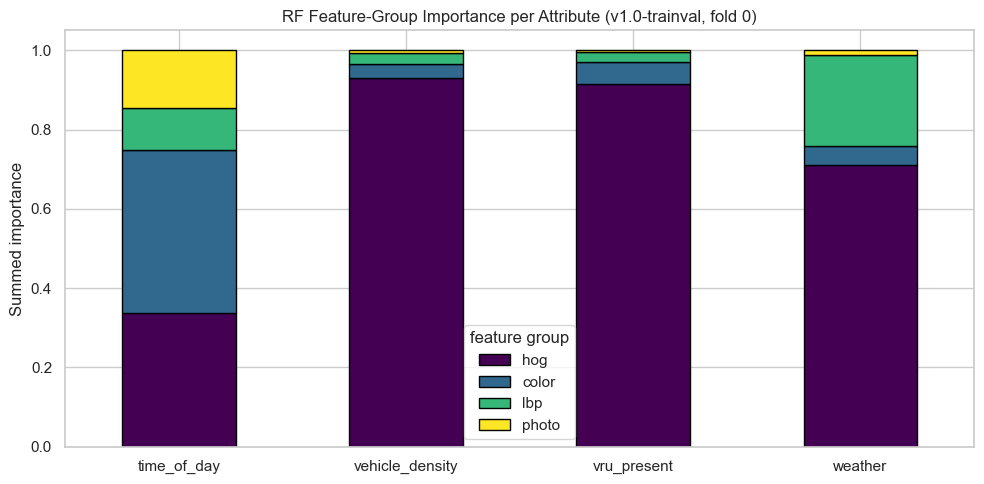

In [5]:
def col_group(c):
    for g in ['hog','color','lbp','photo']:
        if c.startswith(g+'_'): return g
    return 'other'
recs=[]
for attr,rf in rf_models.items():
    for col,imp in zip(FEATURE_COLS,rf.feature_importances_):
        recs.append({'attribute':attr,'group':col_group(col),'importance':float(imp)})
df_imp=pd.DataFrame(recs)
group_imp=(df_imp.groupby(['attribute','group'])['importance'].sum().unstack('group')
           .reindex(columns=['hog','color','lbp','photo']).round(4))
group_imp.to_csv(FINAL_DIR/'feature_importance_rf_groups.csv')
print('=== RF FEATURE-GROUP IMPORTANCE (summed) ==='); print(group_imp)

fig,ax=plt.subplots(figsize=(10,5))
group_imp.plot(kind='bar',stacked=True,ax=ax,colormap='viridis',edgecolor='black')
ax.set_title('RF Feature-Group Importance per Attribute (v1.0-trainval, fold 0)')
ax.set_ylabel('Summed importance'); ax.set_xlabel(''); ax.tick_params(axis='x',rotation=0)
ax.legend(title='feature group'); plt.tight_layout()
plt.savefig(FIG_DIR/'feature_importance_groups.png',bbox_inches='tight',dpi=120); plt.show()

## 4. Stratified Error Analysis (from saved OOF predictions)

In [6]:
df_preds=pd.read_csv(PRED_DIR/'predictions_test.csv')
tuned_p=df_preds[(df_preds.version=='tuned')&(df_preds.seed==SEED)]
print('=== MOST-CONFUSED CLASS PAIRS per attribute (best-model OOF) ===')
err_summary=[]
tuned_m=pd.read_csv(RESULTS_DIR/'all_metrics.csv')
tuned_m=tuned_m[tuned_m.version=='tuned']
for attr in ATTRIBUTES:
    bm=tuned_m[tuned_m.attribute==attr].groupby('model')['macro_f1'].mean().idxmax()
    sub=tuned_p[(tuned_p.attribute==attr)&(tuned_p.model==bm)]
    wrong=sub[sub.y_true!=sub.y_pred]
    if len(sub)==0: continue
    err_rate=len(wrong)/len(sub)
    pair=(wrong.groupby(['y_true','y_pred']).size().sort_values(ascending=False).head(1))
    top_pair=f'{pair.index[0][0]}->{pair.index[0][1]} (n={pair.iloc[0]})' if len(pair) else 'none'
    err_summary.append({'attribute':attr,'best_model':bm,'error_rate':round(err_rate,3),
                        'top_confusion':top_pair})
df_err=pd.DataFrame(err_summary); df_err.to_csv(FINAL_DIR/'error_analysis.csv',index=False)
print(df_err.to_string(index=False))

=== MOST-CONFUSED CLASS PAIRS per attribute (best-model OOF) ===
      attribute   best_model  error_rate            top_confusion
    time_of_day      XGBoost       0.004        night->day (n=22)
        weather RandomForest       0.057      rain->clear (n=278)
vehicle_density      SVM_RBF       0.481      medium->low (n=838)
    vru_present      SVM_RBF       0.364 present->absent (n=1269)


## 5. Research-Question Summary (drawn on trainval)

In [7]:
headline=pd.read_csv(FINAL_DIR/'headline_table.csv') if (FINAL_DIR/'headline_table.csv').exists() else None
print('='*72); print('RESEARCH QUESTIONS — answered on v1.0-trainval (primary experiment)'); print('='*72)
if headline is not None:
    print('\nRQ2 — Attribute learnability hierarchy (best macro-F1):')
    for _,r in headline.sort_values('macro_f1',ascending=False).iterrows():
        print(f'  {r["attribute"]:18s}: {r["macro_f1"]:.3f} ({r["best_model"]})')
print('\nRQ4 — Dominant feature group per attribute (RF):')
for attr in group_imp.index:
    print(f'  {attr:18s}: {group_imp.loc[attr].idxmax()}')
print('\n[WRITE: RQ1 (can classical features do it — yes for photometric, ceiling for structural),')
print(' RQ3 (most consistent model — from 06a ranking), RQ5 (tuning effect — from 06b stats)]')

RESEARCH QUESTIONS — answered on v1.0-trainval (primary experiment)

RQ2 — Attribute learnability hierarchy (best macro-F1):
  time_of_day       : 0.993 (XGB)
  weather           : 0.901 (RF)
  vru_present       : 0.628 (SVM)
  vehicle_density   : 0.511 (SVM)

RQ4 — Dominant feature group per attribute (RF):
  time_of_day       : color
  vehicle_density   : hog
  vru_present       : hog
  weather           : hog

[WRITE: RQ1 (can classical features do it — yes for photometric, ceiling for structural),
 RQ3 (most consistent model — from 06a ranking), RQ5 (tuning effect — from 06b stats)]


## 6. Final Summary JSON

In [8]:
final={'dataset_version':DV,
       'feature_group_dominant':{a:group_imp.loc[a].idxmax() for a in group_imp.index},
       'error_analysis':[r for r in df_err.to_dict('records')]}
with open(FINAL_DIR/'deep_analysis_summary.json','w') as f: json.dump(final,f,indent=2,default=str)
print('Saved ->',FINAL_DIR/'deep_analysis_summary.json'); print(json.dumps(final,indent=2,default=str))

Saved -> results\v1.0-trainval\final\deep_analysis_summary.json
{
  "dataset_version": "v1.0-trainval",
  "feature_group_dominant": {
    "time_of_day": "color",
    "vehicle_density": "hog",
    "vru_present": "hog",
    "weather": "hog"
  },
  "error_analysis": [
    {
      "attribute": "time_of_day",
      "best_model": "XGBoost",
      "error_rate": 0.004,
      "top_confusion": "night->day (n=22)"
    },
    {
      "attribute": "weather",
      "best_model": "RandomForest",
      "error_rate": 0.057,
      "top_confusion": "rain->clear (n=278)"
    },
    {
      "attribute": "vehicle_density",
      "best_model": "SVM_RBF",
      "error_rate": 0.481,
      "top_confusion": "medium->low (n=838)"
    },
    {
      "attribute": "vru_present",
      "best_model": "SVM_RBF",
      "error_rate": 0.364,
      "top_confusion": "present->absent (n=1269)"
    }
  ]
}


## Conclusions

This study shows that classical machine learning with handcrafted visual features can successfully classify some autonomous-driving scene attributes, but its effectiveness depends strongly on the type of attribute being predicted. On the full `v1.0-trainval` experiment, the photometric attributes were clearly the easiest. `time_of_day` achieved the strongest result with XGB, reaching a macro-F1 score of **0.993**, while `weather` achieved a strong macro-F1 score of **0.901** using Random Forest. These results show that classical features are sufficient when the target attribute is strongly related to global image appearance, such as brightness, colour distribution, contrast, texture, and lighting condition.

The feature-importance analysis supports this conclusion. For `time_of_day`, colour features were the dominant feature group, which is expected because day and night scenes differ strongly in illumination and colour intensity. For `weather`, HOG was the dominant group, with LBP also contributing, suggesting that rain-related appearance is captured through gradient and texture patterns. Notably, `time_of_day` draws on a balanced mix of feature groups (colour 0.41, HOG 0.34, photometric 0.15, LBP 0.11), whereas the structural attributes rely almost entirely on a single group. This contrast is itself revealing: the photometric attribute can exploit multiple complementary cues, while the structural attributes are forced to depend on one feature type. Therefore, for photometric scene understanding, the engineered feature set provides enough information for reliable classification.

In contrast, the structural attributes showed a clear performance ceiling. `vehicle_density` achieved only **0.511** macro-F1, while `vru_present` reached **0.628**, both using SVM. These scores are still above random and majority baselines, meaning the models learned useful signals, but the performance is much lower than the photometric attributes. The severity of the ceiling is notable: even the best model misclassifies around **48%** of `vehicle_density` samples and **36%** of `vru_present` samples. The error analysis explains this limitation. For `vehicle_density`, the main confusion occurs between neighbouring density levels, especially medium-density scenes being predicted as low. For `vru_present`, the main error is present scenes being predicted as absent. This suggests that the model struggles when the task requires object counting, localisation, or recognition of small road users.

The feature-importance results also support this feature-ceiling argument. Both `vehicle_density` and `vru_present` are heavily dominated by HOG features (0.93 and 0.92 respectively), but HOG only describes gradient and shape patterns in a general image-level manner. It does not explicitly count vehicles, detect pedestrians, localise cyclists, or reason about object positions. The fact that these attributes lean almost entirely on HOG, yet still cannot exceed the ceiling, indicates that the limitation is not a lack of the right feature group but the inability of holistic features to perform object-level reasoning at all. Therefore, although HOG provides some structural cues, it is not strong enough to fully solve object-level scene understanding. Better performance for these attributes would likely require object-detection features, bounding-box counts, depth or distance information, semantic segmentation, or temporal cues across frames.

The research questions can therefore be answered as follows. **RQ1:** Classical machine learning with handcrafted features is effective for photometric attributes, but limited for structural attributes. **RQ2:** The learnability hierarchy is clear: `time_of_day` is easiest, followed by `weather`, then `vru_present`, with `vehicle_density` being the hardest. **RQ3:** XGB is the strongest overall model based on the headline ranking, although SVM is the best model for the two harder structural attributes. **RQ4:** The dominant feature groups differ by attribute: colour features are most important for `time_of_day`, while HOG dominates `weather`, `vehicle_density`, and `vru_present`. **RQ5:** Hyperparameter tuning gives small and mixed improvements, but it does not fundamentally change the main conclusion because the limiting factor is the feature representation rather than only model optimisation.

Finally, the earlier `v1.0-mini` experiment should be treated only as a pilot study. It was useful for checking the workflow, feature extraction process, modelling pipeline, and initial trends, but its smaller size was insufficient for reliable final evaluation. The conclusions in this notebook are therefore drawn from the larger `v1.0-trainval` experiment, which provides a more trustworthy basis for evaluating model performance, attribute difficulty, error patterns, and feature limitations.